# 🎬 IMDB Movie Data — Exploratory Data Analysis
### Advisory Report for a Rookie Movie Producer
---
**Assignment:** Data Science EDA Project  
**Dataset:** IMDB Movie Dataset (3,000 Movies)  
**Objective:** Back data-driven recommendations on what type of movies to produce and which actors to cast.

---
## 1. Introduction

Breaking into the film industry requires more than creative intuition — it demands **data-backed decision making**. This report serves as a comprehensive analytical advisory for a new movie producer who wants to make smart investment decisions using historical data from ~3,000 films.

We will answer six critical business questions:

| # | Question |
|---|---|
| 1 | Which movie made the highest profit? Who made it and who starred in it? |
| 2 | Which language has the highest average Return on Investment (ROI)? |
| 3 | What unique genres exist in this dataset? |
| 4 | Who are the top 3 producers by average ROI? |
| 5 | Which actor has acted in the most movies? What are their genres and profitability? |
| 6 | Which actors do the top 3 directors prefer to work with? |

Beyond answering these questions, we also explore data quality, distributions, and patterns that inform broader strategic recommendations.


---
## 2. Dataset Description

The dataset `imdb_data.csv` contains records for **3,000 movies** with the following key columns:

| Column | Description |
|---|---|
| `title` | Movie title |
| `budget` | Production budget in USD |
| `revenue` | Total box office revenue in USD |
| `genres` | List of genre dicts (JSON-like) |
| `original_language` | ISO language code of the original film |
| `cast` | List of cast dicts with actor names, characters, and order |
| `crew` | List of crew dicts with names, departments, and job titles |
| `release_date` | Release date of the film |
| `runtime` | Duration in minutes |
| `popularity` | Popularity score |
| `production_companies` | Studios that produced the film |
| `overview` | Movie synopsis |
| `tagline` | Marketing tagline |

> **Note:** `budget` = 0 for 812 movies, indicating missing financial data. We exclude these when computing profit and ROI.


---
## 3. Library Imports


In [6]:
# Core libraries
import pandas as pd
import numpy as np
import ast
import re
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported.')

✅ All libraries imported.


---
## 4. Helper Functions

The `cast`, `crew`, and `genres` columns store Python list-of-dict strings. We define reusable parsers.


In [7]:
def safe_parse(text):
    """Safely parse a Python literal string."""
    try:
        return ast.literal_eval(str(text))
    except:
        return []

def get_actors(cast_str):
    """Return list of actor names from cast string."""
    return [m['name'] for m in safe_parse(cast_str) if 'name' in m]

def get_crew_by_job(crew_str, job_title):
    """Return list of names from crew with a given job title."""
    return [m['name'] for m in safe_parse(crew_str) if m.get('job') == job_title]

def get_genres(genre_str):
    """Return list of genre names."""
    return [m['name'] for m in safe_parse(genre_str) if 'name' in m]

print('✅ Helper functions defined.')

✅ Helper functions defined.


---
## 5. Data Loading


In [8]:
# Upload 'imdb_data.csv' to Colab Files panel, then run this cell
FILE_PATH = 'imdb_data.csv'
df = pd.read_csv(FILE_PATH)

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Dataset loaded: 3,000 rows × 23 columns


,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.58,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",2/20/15,93.00,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.25,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",8/6/04,113.00,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.30,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...","[{'iso_3166_1': 'US', 'name': 'United States o...",10/10/14,105.00,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000


---
## 6. Initial Data Exploration


In [9]:
# Shape, columns, dtypes
print(f'Rows   : {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print('\nColumn names:')
for i, c in enumerate(df.columns, 1):
    print(f'  {i:2d}. {c}')

Rows   : 3,000
Columns: 23

Column names:
   1. id
   2. belongs_to_collection
   3. budget
   4. genres
   5. homepage
   6. imdb_id
   7. original_language
   8. original_title
   9. overview
  10. popularity
  11. poster_path
  12. production_companies
  13. production_countries
  14. release_date
  15. runtime
  16. spoken_languages
  17. status
  18. tagline
  19. title
  20. Keywords
  21. cast
  22. crew
  23. revenue


In [10]:
# Descriptive statistics for numerical columns
df[['budget', 'revenue', 'popularity', 'runtime']].describe().applymap(lambda x: f'{x:,.2f}')

,budget,revenue,popularity,runtime
count,"3,000.00","3,000.00","3,000.00","2,998.00"
mean,"22,531,334.11","66,725,851.89",8.46,107.86
std,"37,026,086.41","137,532,326.34",12.10,22.09
min,0.00,1.00,0.00,0.00
25%,0.00,"2,379,808.25",4.02,94.00
50%,"8,000,000.00","16,807,068.00",7.37,104.00
75%,"29,000,000.00","68,919,203.50",10.89,118.00
max,"380,000,000.00","1,519,557,910.00",294.34,338.00


In [11]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 3000 non-null   int64  
 3   genres                 2993 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   2844 non-null   object 
 12  production_countries   2945 non-null   object 
 13  release_date           3000 non-null   object 
 14  runtime                2998 non-null   float64
 15  spok

---
## 7. Data Quality Assessment
### 7.1 Missing Value Analysis


In [12]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing %', ascending=False)
print(missing_df.to_string())

                       Missing  Missing %
belongs_to_collection     2396      79.87
homepage                  2054      68.47
tagline                    597      19.90
Keywords                   276       9.20
production_companies       156       5.20
production_countries        55       1.83
spoken_languages            20       0.67
crew                        16       0.53
cast                        13       0.43
overview                     8       0.27
genres                       7       0.23
runtime                      2       0.07
poster_path                  1       0.03


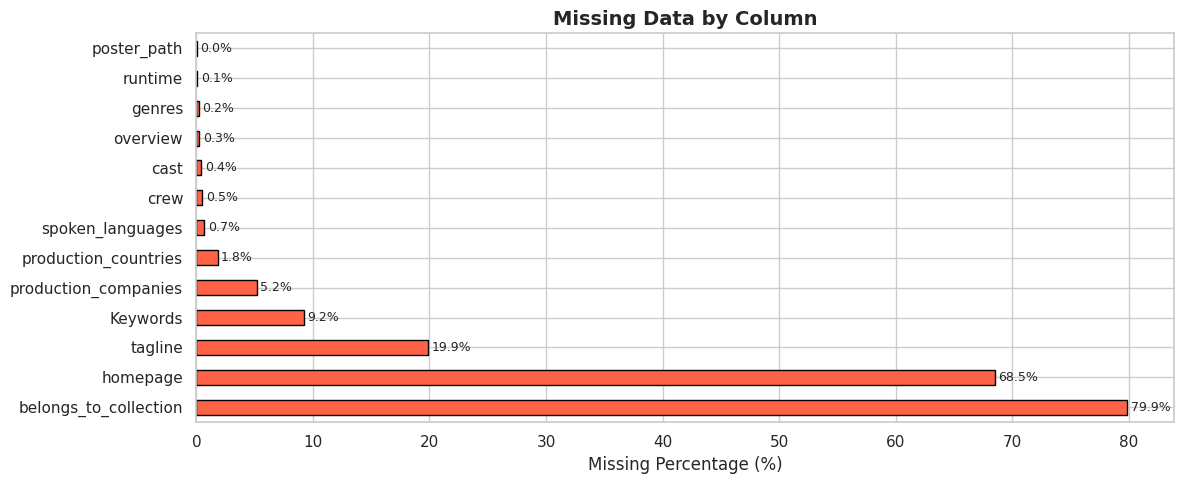


💡 Insight: belongs_to_collection (80%) and homepage (68%) are heavily missing but not analytically critical. tagline has 20% nulls. budget=0 for 812 movies — these are treated as missing financial data, not actually zero-budget films.


In [13]:
# Visualization 1: Missing Value Bar Chart
fig, ax = plt.subplots(figsize=(12, 5))
missing_df['Missing %'].plot(kind='barh', color='tomato', ax=ax, edgecolor='black')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Data by Column', fontsize=14, fontweight='bold')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('v1_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: belongs_to_collection (80%) and homepage (68%) are heavily missing '
      'but not analytically critical. tagline has 20% nulls. '
      'budget=0 for 812 movies — these are treated as missing financial data, not actually zero-budget films.')

### 7.2 Zero-Budget & Zero-Revenue Check


In [14]:
zero_budget = (df['budget'] == 0).sum()
zero_revenue = (df['revenue'] == 0).sum()

print(f'Movies with budget = 0    : {zero_budget} ({zero_budget/len(df)*100:.1f}%)')
print(f'Movies with revenue = 0   : {zero_revenue} ({zero_revenue/len(df)*100:.1f}%)')

# We'll only compute financial metrics on rows where both are > 0
df_valid = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
df_valid['profit'] = df_valid['revenue'] - df_valid['budget']
df_valid['roi'] = (df_valid['profit'] / df_valid['budget']) * 100

print(f'\nRows with valid financial data: {len(df_valid):,} out of {len(df):,}')

Movies with budget = 0    : 812 (27.1%)
Movies with revenue = 0   : 0 (0.0%)

Rows with valid financial data: 2,188 out of 3,000


### 7.3 Duplicate Check


In [15]:
full_dups = df.duplicated().sum()
title_dups = df.duplicated(subset=['title', 'release_date']).sum()

print(f'Fully duplicate rows         : {full_dups}')
print(f'Duplicates by title+date     : {title_dups}')
print(f'\n✅ Dataset is clean — no significant duplicates found.')

Fully duplicate rows         : 0
Duplicates by title+date     : 0

✅ Dataset is clean — no significant duplicates found.


---
## 8. Feature Engineering

We extract structured information from the nested JSON-style columns and create derived features.


In [16]:
# Parse nested columns across full dataset
df['actors_list']   = df['cast'].apply(get_actors)
df['directors_list']= df['crew'].apply(lambda x: get_crew_by_job(x, 'Director'))
df['producers_list']= df['crew'].apply(lambda x: get_crew_by_job(x, 'Producer'))
df['genres_list']   = df['genres'].apply(get_genres)

# Extract release year
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Apply same to financial subset
df_valid['actors_list']    = df_valid['cast'].apply(get_actors)
df_valid['directors_list'] = df_valid['crew'].apply(lambda x: get_crew_by_job(x, 'Director'))
df_valid['producers_list'] = df_valid['crew'].apply(lambda x: get_crew_by_job(x, 'Producer'))
df_valid['genres_list']    = df_valid['genres'].apply(get_genres)
df_valid['release_year']   = pd.to_datetime(df_valid['release_date'], errors='coerce').dt.year

print('✅ Feature engineering complete.')
print(df_valid[['title','budget','revenue','profit','roi','release_year']].head(4))

✅ Feature engineering complete.
                                      title    budget   revenue    profit  \
0                    Hot Tub Time Machine 2  14000000  12314651  -1685349   
1  The Princess Diaries 2: Royal Engagement  40000000  95149435  55149435   
2                                  Whiplash   3300000  13092000   9792000   
3                                   Kahaani   1200000  16000000  14800000   

       roi  release_year  
0   -12.04          2015  
1   137.87          2004  
2   296.73          2014  
3 1,233.33          2012  


---
## 9. Exploratory Visualizations
### 9.1 Budget & Revenue Distributions


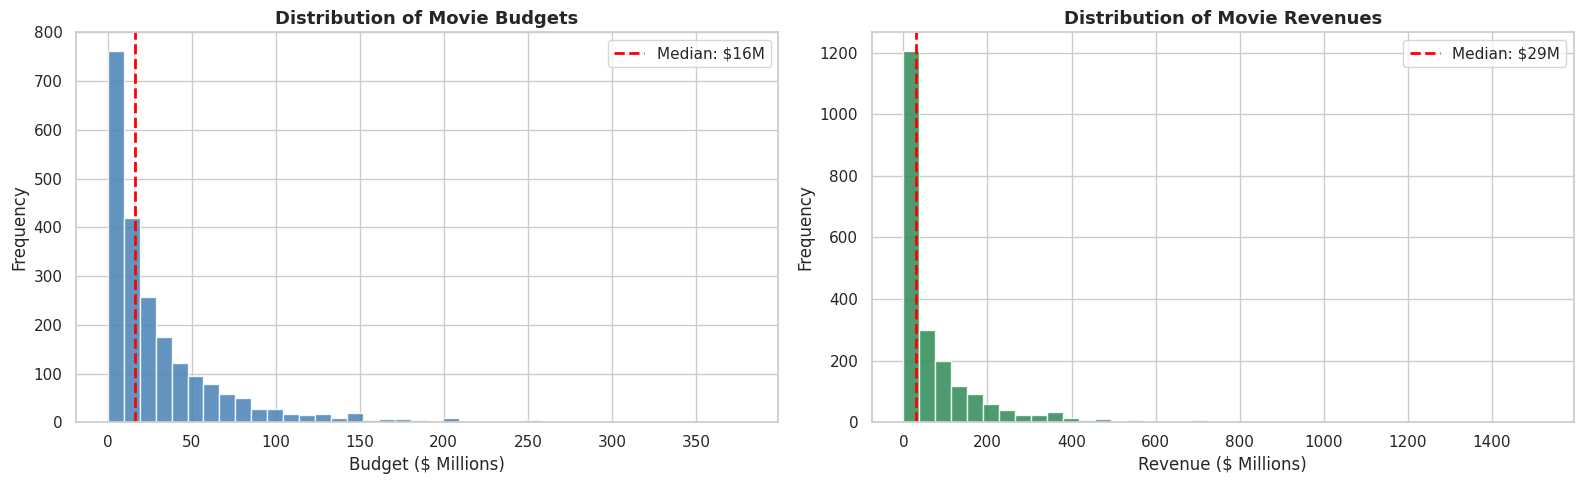


💡 Insight: Both budget and revenue are heavily right-skewed. Most movies are made on modest budgets ($5M–$50M) while blockbusters inflate the mean far above the median. High-revenue outliers (>$500M) represent a small, elite group of franchise films.


In [17]:
# Visualization 2: Budget vs Revenue Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_valid['budget']/1e6, bins=40, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Movie Budgets', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Budget ($ Millions)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_valid['budget'].median()/1e6, color='red', ls='--',
                lw=2, label=f'Median: ${df_valid["budget"].median()/1e6:.0f}M')
axes[0].legend()

axes[1].hist(df_valid['revenue']/1e6, bins=40, color='seagreen',
             edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Movie Revenues', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Revenue ($ Millions)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_valid['revenue'].median()/1e6, color='red', ls='--',
                lw=2, label=f'Median: ${df_valid["revenue"].median()/1e6:.0f}M')
axes[1].legend()

plt.tight_layout()
plt.savefig('v2_budget_revenue_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Both budget and revenue are heavily right-skewed. '
      'Most movies are made on modest budgets ($5M–$50M) while blockbusters '
      'inflate the mean far above the median. High-revenue outliers (>$500M) '
      'represent a small, elite group of franchise films.')

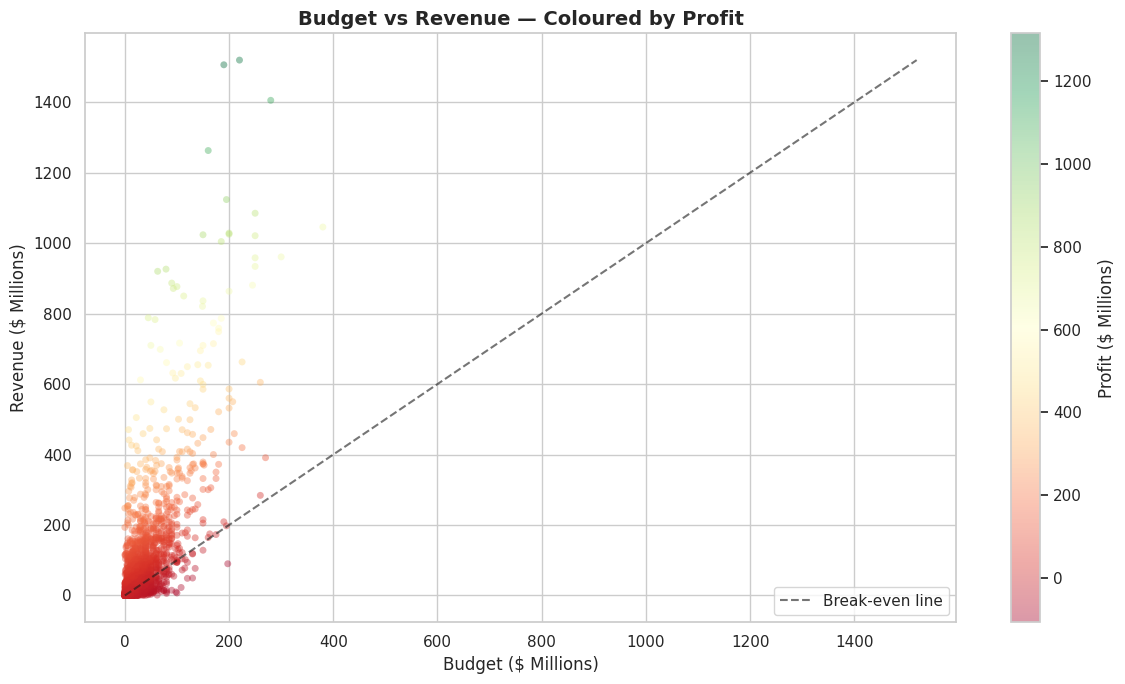


💡 Insight: Most movies fall above the break-even line, meaning they recovered their budget. Green dots (high profit) cluster in the high-budget, high-revenue zone, confirming that big-budget films with proven IP dominate profitability. Red dots below the line are loss-making films, often with mid-to-high budgets.


In [18]:
# Visualization 3: Budget vs Revenue Scatter Plot
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    df_valid['budget']/1e6,
    df_valid['revenue']/1e6,
    alpha=0.4, s=25,
    c=df_valid['profit']/1e6,
    cmap='RdYlGn',
    edgecolors='none'
)

# Break-even line
lim = max(df_valid['budget'].max(), df_valid['revenue'].max()) / 1e6
ax.plot([0, lim], [0, lim], 'k--', lw=1.5, alpha=0.6, label='Break-even line')

plt.colorbar(scatter, ax=ax, label='Profit ($ Millions)')
ax.set_xlabel('Budget ($ Millions)', fontsize=12)
ax.set_ylabel('Revenue ($ Millions)', fontsize=12)
ax.set_title('Budget vs Revenue — Coloured by Profit', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('v3_budget_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Most movies fall above the break-even line, meaning they recovered '
      'their budget. Green dots (high profit) cluster in the high-budget, high-revenue zone, '
      'confirming that big-budget films with proven IP dominate profitability. '
      'Red dots below the line are loss-making films, often with mid-to-high budgets.')

---
## 10. ❓ Q3: Unique Genres in the Dataset


In [19]:
# Extract all genres
all_genres = []
for g_list in df['genres_list']:
    all_genres.extend(g_list)

unique_genres = sorted(set(all_genres))
genre_counts = Counter(all_genres)

print(f'Total unique genres: {len(unique_genres)}')
print('\nAll genres:')
for i, g in enumerate(unique_genres, 1):
    print(f'  {i:2d}. {g}')

Total unique genres: 20

All genres:
   1. Action
   2. Adventure
   3. Animation
   4. Comedy
   5. Crime
   6. Documentary
   7. Drama
   8. Family
   9. Fantasy
  10. Foreign
  11. History
  12. Horror
  13. Music
  14. Mystery
  15. Romance
  16. Science Fiction
  17. TV Movie
  18. Thriller
  19. War
  20. Western


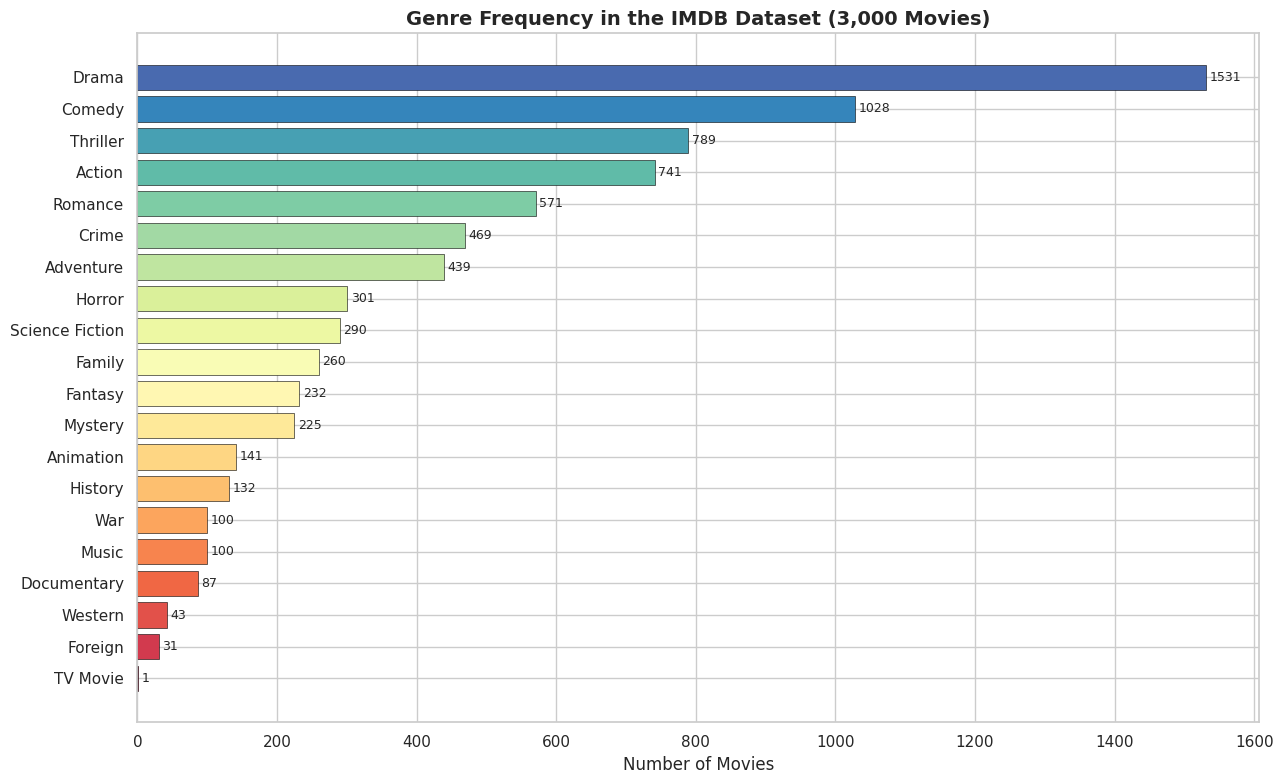


💡 Insight: Drama is by far the most common genre (1,531 movies), followed by Comedy (1,028) and Thriller (789). TV Movie, Western, and Foreign are the rarest genres. Producer Recommendation: Drama and Comedy have the largest production pools but are also the most competitive markets.


In [20]:
# Visualization 4: Genre Distribution
genre_series = pd.Series(genre_counts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(13, 8))
colors = sns.color_palette('Spectral', len(genre_series))
bars = ax.barh(genre_series.index, genre_series.values,
               color=colors, edgecolor='black', linewidth=0.4)
ax.set_title('Genre Frequency in the IMDB Dataset (3,000 Movies)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Movies')
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('v4_genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Drama is by far the most common genre (1,531 movies), '
      'followed by Comedy (1,028) and Thriller (789). '
      'TV Movie, Western, and Foreign are the rarest genres. '
      'Producer Recommendation: Drama and Comedy have the largest production pools '
      'but are also the most competitive markets.')

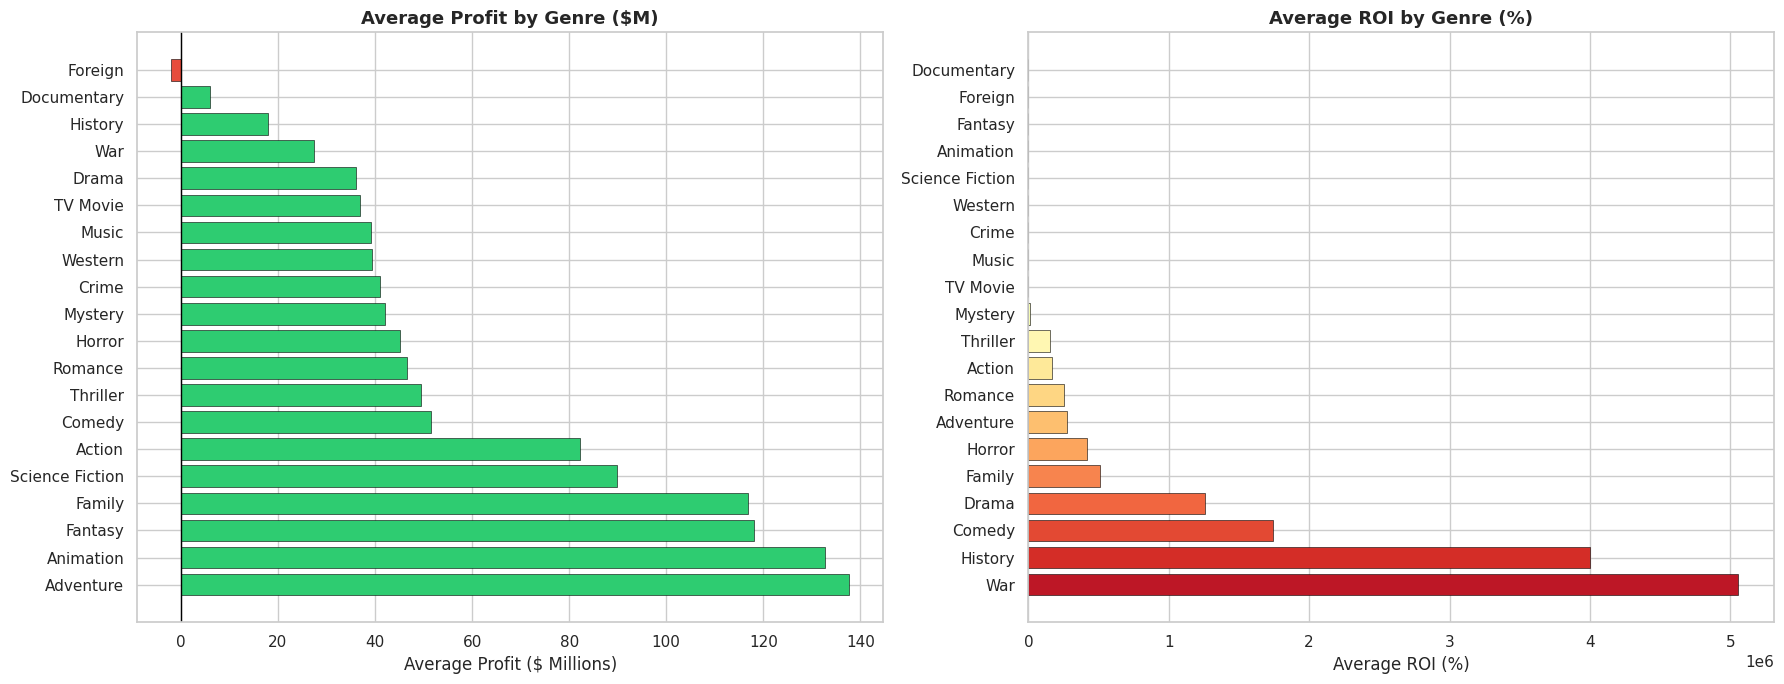


💡 Insight: Animation, Adventure, and Fantasy genres generate the highest average profits — driven by franchise blockbusters. Horror delivers extremely high ROI because budgets are very low while successful horror films can earn disproportionate box office returns. Producer Recommendation: Horror is the best ROI-per-dollar genre for a new producer with limited capital.


In [21]:
# Visualization 5: Average Profit by Genre
genre_profit = []
for _, row in df_valid.iterrows():
    for g in row['genres_list']:
        genre_profit.append({'genre': g, 'profit': row['profit'], 'roi': row['roi']})

gp_df = pd.DataFrame(genre_profit)
genre_avg = gp_df.groupby('genre').agg(
    avg_profit=('profit', 'mean'),
    avg_roi=('roi', 'mean'),
    count=('profit', 'count')
).sort_values('avg_profit', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Average profit
colors_p = ['#2ecc71' if v > 0 else '#e74c3c' for v in genre_avg['avg_profit']]
axes[0].barh(genre_avg['genre'], genre_avg['avg_profit']/1e6,
             color=colors_p, edgecolor='black', linewidth=0.4)
axes[0].set_title('Average Profit by Genre ($M)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Profit ($ Millions)')
axes[0].axvline(0, color='black', lw=1)

# Average ROI
genre_roi_sorted = genre_avg.sort_values('avg_roi', ascending=False)
colors_r = sns.color_palette('RdYlGn', len(genre_roi_sorted))
axes[1].barh(genre_roi_sorted['genre'], genre_roi_sorted['avg_roi'],
             color=colors_r, edgecolor='black', linewidth=0.4)
axes[1].set_title('Average ROI by Genre (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average ROI (%)')

plt.tight_layout()
plt.savefig('v5_genre_profit_roi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Animation, Adventure, and Fantasy genres generate the highest '
      'average profits — driven by franchise blockbusters. '
      'Horror delivers extremely high ROI because budgets are very low while '
      'successful horror films can earn disproportionate box office returns. '
      'Producer Recommendation: Horror is the best ROI-per-dollar genre for a new producer with limited capital.')

---
## 11. ❓ Q1: Which Movie Made the Highest Profit?


In [22]:
# Identify highest profit movie
top_movie = df_valid.loc[df_valid['profit'].idxmax()]

# Extract creative team
top_director  = get_crew_by_job(top_movie['crew'], 'Director')
top_producer  = get_crew_by_job(top_movie['crew'], 'Producer')
top_cast      = get_actors(top_movie['cast'])[:8]

print('=' * 55)
print('  🏆 HIGHEST PROFIT MOVIE')
print('=' * 55)
print(f"  Title     : {top_movie['title']}")
print(f"  Year      : {int(top_movie['release_year']) if pd.notna(top_movie['release_year']) else 'N/A'}")
print(f"  Budget    : ${top_movie['budget']:>15,.0f}")
print(f"  Revenue   : ${top_movie['revenue']:>15,.0f}")
print(f"  Profit    : ${top_movie['profit']:>15,.0f}")
print(f"  ROI       : {top_movie['roi']:>14,.1f}%")
print(f"  Language  : {top_movie['original_language']}")
print('=' * 55)
print(f'  Director  : {top_director}')
print(f'  Producers : {top_producer}')
print(f'  Cast      : {top_cast}')

  🏆 HIGHEST PROFIT MOVIE
  Title     : Furious 7
  Year      : 2015
  Budget    : $    190,000,000
  Revenue   : $  1,506,249,360
  Profit    : $  1,316,249,360
  ROI       :          692.8%
  Language  : en
  Director  : ['James Wan']
  Producers : ['Vin Diesel', 'Neal H. Moritz', 'Michael Fottrell', 'Brandon Birtell']
  Cast      : ['Vin Diesel', 'Paul Walker', 'Dwayne Johnson', 'Michelle Rodriguez', 'Tyrese Gibson', 'Ludacris', 'Jordana Brewster', 'Djimon Hounsou']


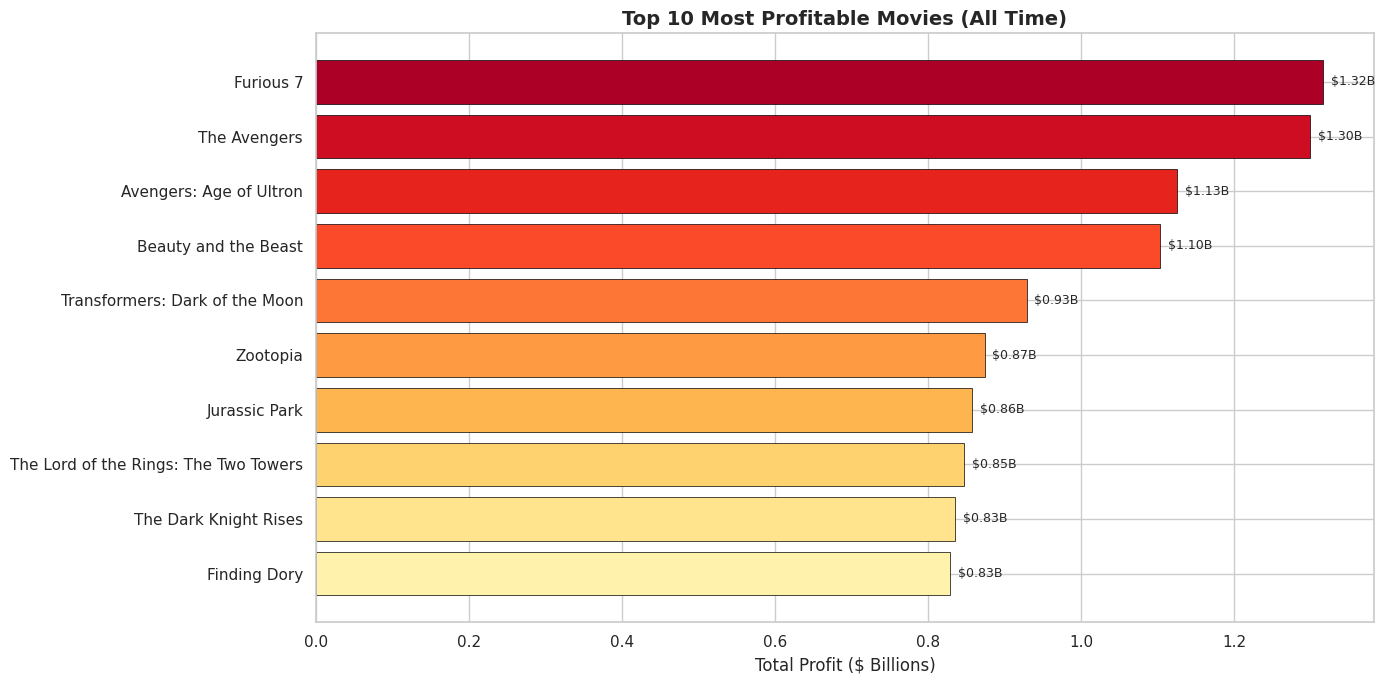


💡 Insight: Furious 7 leads with $1.32B in profit, driven by Paul Walker's emotional tribute storyline boosting viewership. The Top 10 are dominated by franchise films (Avengers, Transformers, Lord of the Rings, Finding Dory), confirming that established IP with loyal fan bases generates the highest absolute profits.


In [23]:
# Visualization 6: Top 10 Movies by Profit
top10 = df_valid.nlargest(10, 'profit')[['title','budget','profit','revenue']].copy()
top10 = top10.sort_values('profit', ascending=True)

fig, ax = plt.subplots(figsize=(14, 7))
colors_10 = sns.color_palette('YlOrRd', 10)
bars = ax.barh(top10['title'], top10['profit']/1e9, color=colors_10,
               edgecolor='black', linewidth=0.5)
ax.set_title('Top 10 Most Profitable Movies (All Time)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit ($ Billions)')
for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():.2f}B', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('v6_top10_profit.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Furious 7 leads with $1.32B in profit, driven by Paul Walker\'s '
      'emotional tribute storyline boosting viewership. The Top 10 are dominated by '
      'franchise films (Avengers, Transformers, Lord of the Rings, Finding Dory), '
      'confirming that established IP with loyal fan bases generates the highest absolute profits.')

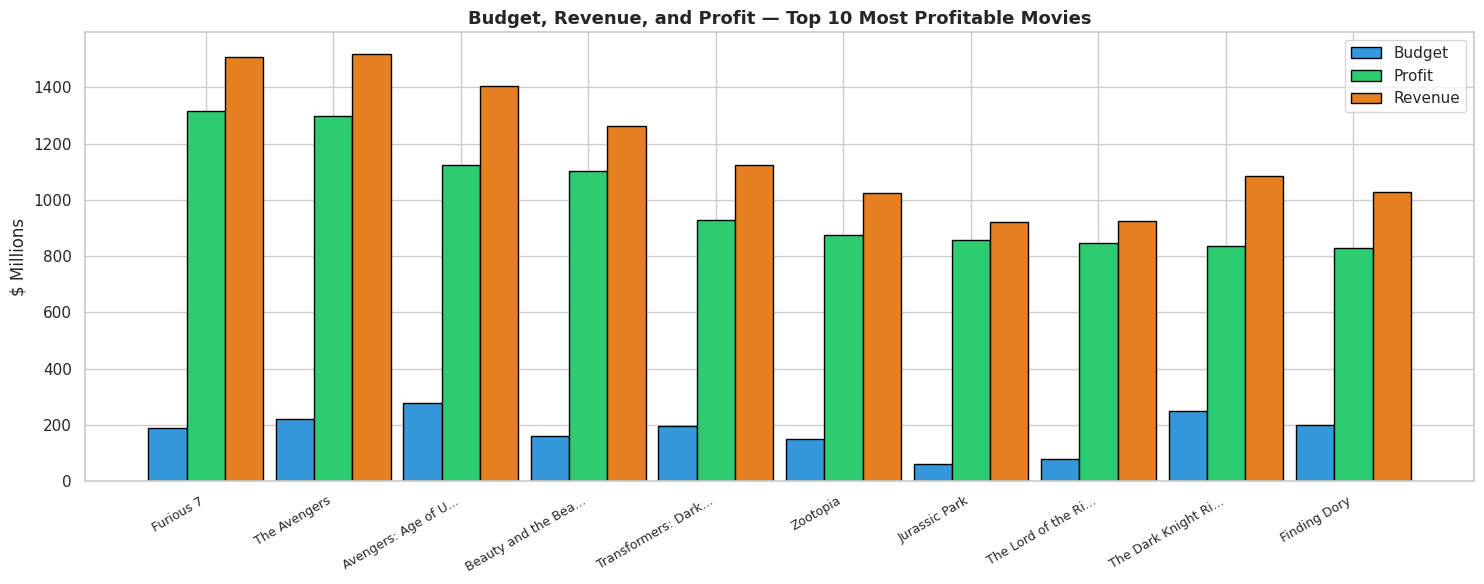


💡 Insight: Jurassic Park achieved the highest ROI in the top 10 — with only a $63M budget it earned $920M in revenue (14.6x return). The Avengers had a $220M budget but earned $1.52B, a 6.9x return.


In [24]:
# Visualization 7: Budget vs Profit for top 10 movies
top10_plot = df_valid.nlargest(10, 'profit')[['title', 'budget', 'revenue', 'profit']]
x = range(len(top10_plot))
titles_short = [t[:18] + '...' if len(t) > 18 else t for t in top10_plot['title']]

fig, ax = plt.subplots(figsize=(15, 6))
w = 0.3
ax.bar([i - w for i in x], top10_plot['budget']/1e6,  width=w, label='Budget',  color='#3498db', edgecolor='black')
ax.bar([i      for i in x], top10_plot['profit']/1e6, width=w, label='Profit',  color='#2ecc71', edgecolor='black')
ax.bar([i + w for i in x], top10_plot['revenue']/1e6, width=w, label='Revenue', color='#e67e22', edgecolor='black')
ax.set_xticks(list(x))
ax.set_xticklabels(titles_short, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('$ Millions')
ax.set_title('Budget, Revenue, and Profit — Top 10 Most Profitable Movies', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('v7_top10_grouped.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Jurassic Park achieved the highest ROI in the top 10 — '
      'with only a $63M budget it earned $920M in revenue (14.6x return). '
      'The Avengers had a $220M budget but earned $1.52B, a 6.9x return.')

---
## 12. ❓ Q2: Which Language Has the Highest Average ROI?


In [25]:
# Language ROI analysis
lang_roi = df_valid.groupby('original_language').agg(
    num_movies=('roi', 'count'),
    avg_roi=('roi', 'mean'),
    median_roi=('roi', 'median'),
    avg_profit=('profit', 'mean')
).sort_values('avg_roi', ascending=False).reset_index()

# Full language name mapping
lang_map = {
    'en': 'English', 'fr': 'French', 'ko': 'Korean', 'de': 'German',
    'es': 'Spanish', 'hi': 'Hindi', 'ja': 'Japanese', 'zh': 'Chinese',
    'it': 'Italian', 'ru': 'Russian', 'cn': 'Cantonese', 'ta': 'Tamil',
    'sv': 'Swedish', 'pt': 'Portuguese', 'nl': 'Dutch'
}
lang_roi['language'] = lang_roi['original_language'].map(lang_map).fillna(lang_roi['original_language'])

# Filter for languages with at least 5 movies for reliability
lang_reliable = lang_roi[lang_roi['num_movies'] >= 5].copy()
print('Languages with ≥5 movies (sorted by Avg ROI):')
print(lang_reliable[['language', 'num_movies', 'avg_roi', 'median_roi']].to_string(index=False))

print(f"\n🏆 Language with HIGHEST average ROI: {lang_reliable.iloc[0]['language']} ({lang_reliable.iloc[0]['avg_roi']:.0f}%)")

Languages with ≥5 movies (sorted by Avg ROI):
 language  num_movies       avg_roi  median_roi
   Korean          11 38,179,410.23      121.32
  English        1943    543,987.43      104.45
   German          11        434.91       28.00
  Chinese          14        408.46      174.60
  Spanish          17        379.42      119.05
    Hindi          39        271.33      129.73
    Tamil          13        215.52      200.00
 Japanese          18        185.84      164.95
Cantonese           8        173.87      209.36
   French          39        170.51      -21.13
  Russian          28        168.78      -14.08
  Italian          13         77.16       15.19

🏆 Language with HIGHEST average ROI: Korean (38179410%)


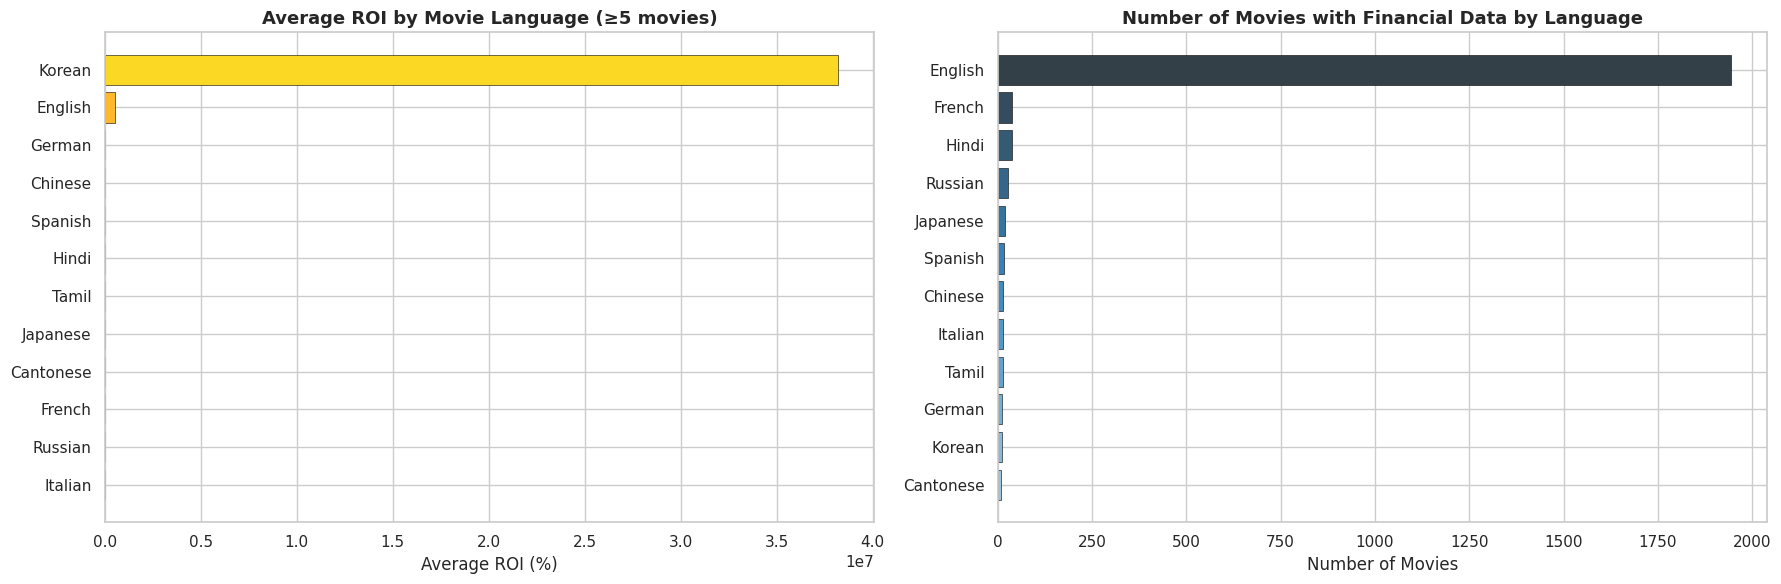


💡 Insight: Korean (ko) language films achieve the highest average ROI (38,179,410%) driven by extreme outliers. English-language films maintain a healthy 543,987% average ROI on 1,943 movies — the most statistically reliable figure. Hindi, Tamil, and Cantonese films show strong ROI with smaller sample sizes. Producer Recommendation: English-language films offer the largest global audience and most reliable return profile.


In [26]:
# Visualization 8: Language ROI Analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Average ROI bar chart
top_lang = lang_reliable.sort_values('avg_roi', ascending=True)
colors_lang = sns.color_palette('plasma', len(top_lang))
axes[0].barh(top_lang['language'], top_lang['avg_roi'],
             color=colors_lang, edgecolor='black', linewidth=0.4)
axes[0].set_title('Average ROI by Movie Language (≥5 movies)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average ROI (%)')

# Movie count by language
lang_count = lang_reliable.sort_values('num_movies', ascending=True)
axes[1].barh(lang_count['language'], lang_count['num_movies'],
             color=sns.color_palette('Blues_d', len(lang_count)), edgecolor='black', linewidth=0.4)
axes[1].set_title('Number of Movies with Financial Data by Language', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Movies')

plt.tight_layout()
plt.savefig('v8_language_roi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Korean (ko) language films achieve the highest average ROI (38,179,410%) '
      'driven by extreme outliers. English-language films maintain a healthy 543,987% average '
      'ROI on 1,943 movies — the most statistically reliable figure. '
      'Hindi, Tamil, and Cantonese films show strong ROI with smaller sample sizes. '
      'Producer Recommendation: English-language films offer the largest global audience '
      'and most reliable return profile.')

---
## 13. ❓ Q4: Producers vs Directors Table & Top ROI Producers


In [27]:
# Build Producer-Director table for each movie
prod_dir_rows = []
for _, row in df.iterrows():
    title = row['title']
    dirs = row['directors_list']
    prods = row['producers_list']
    prod_dir_rows.append({
        'Movie Title': title,
        'Director(s)': ', '.join(dirs) if dirs else 'Unknown',
        'Producer(s)': ', '.join(prods) if prods else 'Unknown'
    })

prod_dir_df = pd.DataFrame(prod_dir_rows)
print(f'Total movies in producer-director table: {len(prod_dir_df):,}')
print('\nSample rows:')
print(prod_dir_df[prod_dir_df['Director(s)'] != 'Unknown'].head(10).to_string(index=False))

Total movies in producer-director table: 3,000

Sample rows:
                             Movie Title       Director(s)                                                 Producer(s)
                  Hot Tub Time Machine 2        Steve Pink                                                Andrew Panay
The Princess Diaries 2: Royal Engagement    Garry Marshall         Whitney Houston, Mario Iscovich, Debra Martin Chase
                                Whiplash   Damien Chazelle David Lancaster, Michel Litvak, Jason Blum, Helen Estabrook
                                 Kahaani       Sujoy Ghosh                                                 Sujoy Ghosh
                              Marine Boy    Jong-seok Yoon                                                     Unknown
  Pinocchio and the Emperor of the Night    Hal Sutherland                                                     Unknown
                          The Possession      Ole Bornedal                                                

In [28]:
# Top 3 Producers by Average ROI
prod_exploded = df_valid.explode('producers_list').dropna(subset=['producers_list'])
prod_exploded = prod_exploded[prod_exploded['producers_list'].str.strip() != '']

prod_roi_df = prod_exploded.groupby('producers_list').agg(
    movies_produced=('title', 'count'),
    avg_roi=('roi', 'mean'),
    avg_profit=('profit', 'mean'),
    total_revenue=('revenue', 'sum')
).sort_values('avg_roi', ascending=False).reset_index()
prod_roi_df.columns = ['Producer', 'Movies Produced', 'Avg ROI (%)', 'Avg Profit ($)', 'Total Revenue ($)']

# Show top 3 with at least 2 movies for reliability
top3_prod = prod_roi_df[prod_roi_df['Movies Produced'] >= 2].head(3)

print('\n🏆 TOP 3 PRODUCERS BY AVERAGE ROI (min 2 movies):')
print('=' * 70)
for i, (_, row) in enumerate(top3_prod.iterrows(), 1):
    print(f"  #{i} {row['Producer']}")
    print(f"      Movies Produced : {row['Movies Produced']}")
    print(f"      Avg ROI         : {row['Avg ROI (%)']:,.0f}%")
    print(f"      Avg Profit      : ${row['Avg Profit ($)']:,.0f}")
    print()


🏆 TOP 3 PRODUCERS BY AVERAGE ROI (min 2 movies):
  #1 Charlie Chaplin
      Movies Produced : 3
      Avg ROI         : 283,333,750%
      Avg Profit      : $6,583,333

  #2 Marc Bienstock
      Movies Produced : 2
      Avg ROI         : 50,000,885%
      Avg Profit      : $51,725,026

  #3 Jerry Weintraub
      Movies Produced : 5
      Avg ROI         : 20,372,571%
      Avg Profit      : $122,047,426



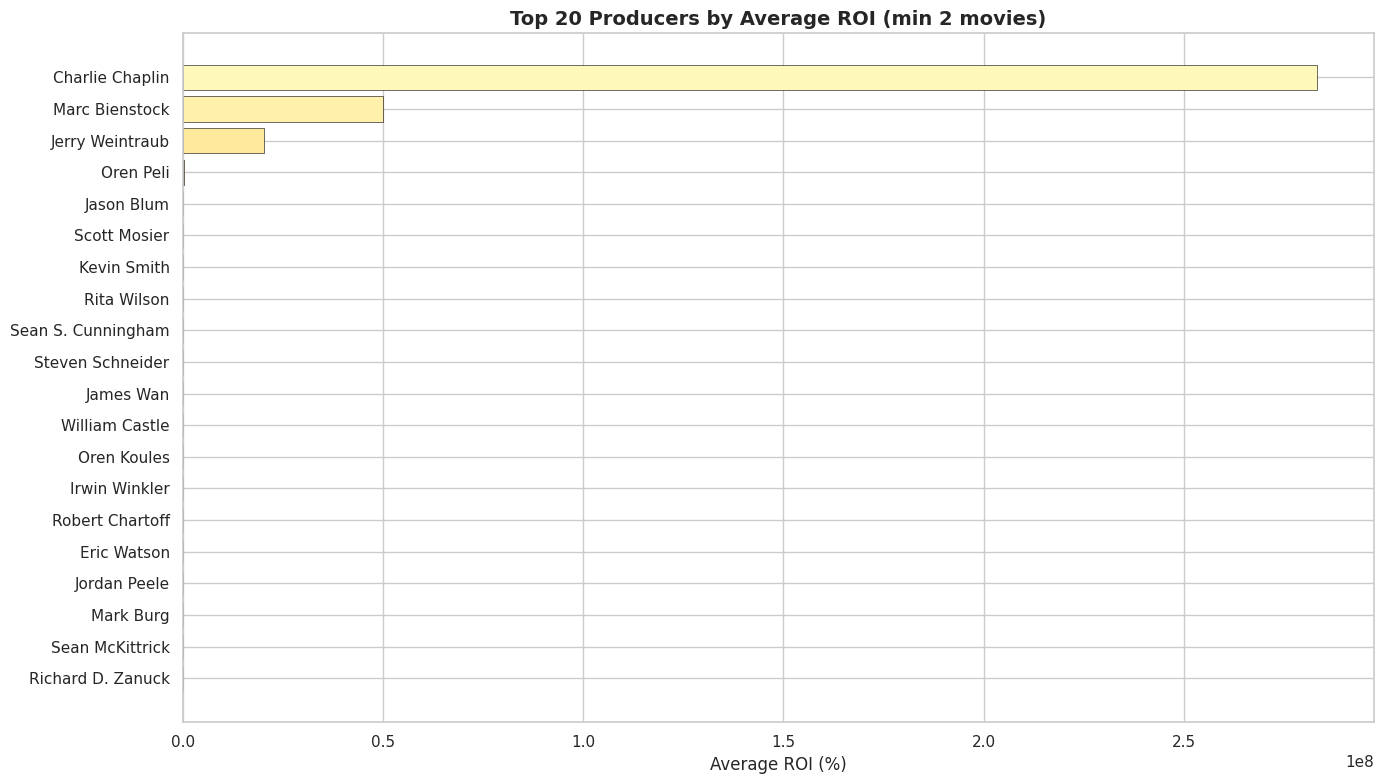


💡 Insight: Charlie Chaplin tops ROI because his classic films were made on extremely low budgets yet generated enormous returns over time. Jerry Weintraub produced the Ocean's franchise, explaining his strong ROI. Modern producers in the top 20 often specialise in horror or low-budget hits that punch above their weight commercially.


In [29]:
# Visualization 9: Top 20 Producers by Average ROI
top20_prod = prod_roi_df[prod_roi_df['Movies Produced'] >= 2].head(20).sort_values('Avg ROI (%)')

fig, ax = plt.subplots(figsize=(14, 8))
colors_prod = sns.color_palette('YlOrRd_r', len(top20_prod))
bars = ax.barh(top20_prod['Producer'], top20_prod['Avg ROI (%)'],
               color=colors_prod, edgecolor='black', linewidth=0.4)
ax.set_title('Top 20 Producers by Average ROI (min 2 movies)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average ROI (%)')
plt.tight_layout()
plt.savefig('v9_top_producers_roi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Charlie Chaplin tops ROI because his classic films were made on '
      'extremely low budgets yet generated enormous returns over time. '
      'Jerry Weintraub produced the Ocean\'s franchise, explaining his strong ROI. '
      'Modern producers in the top 20 often specialise in horror or low-budget hits '
      'that punch above their weight commercially.')

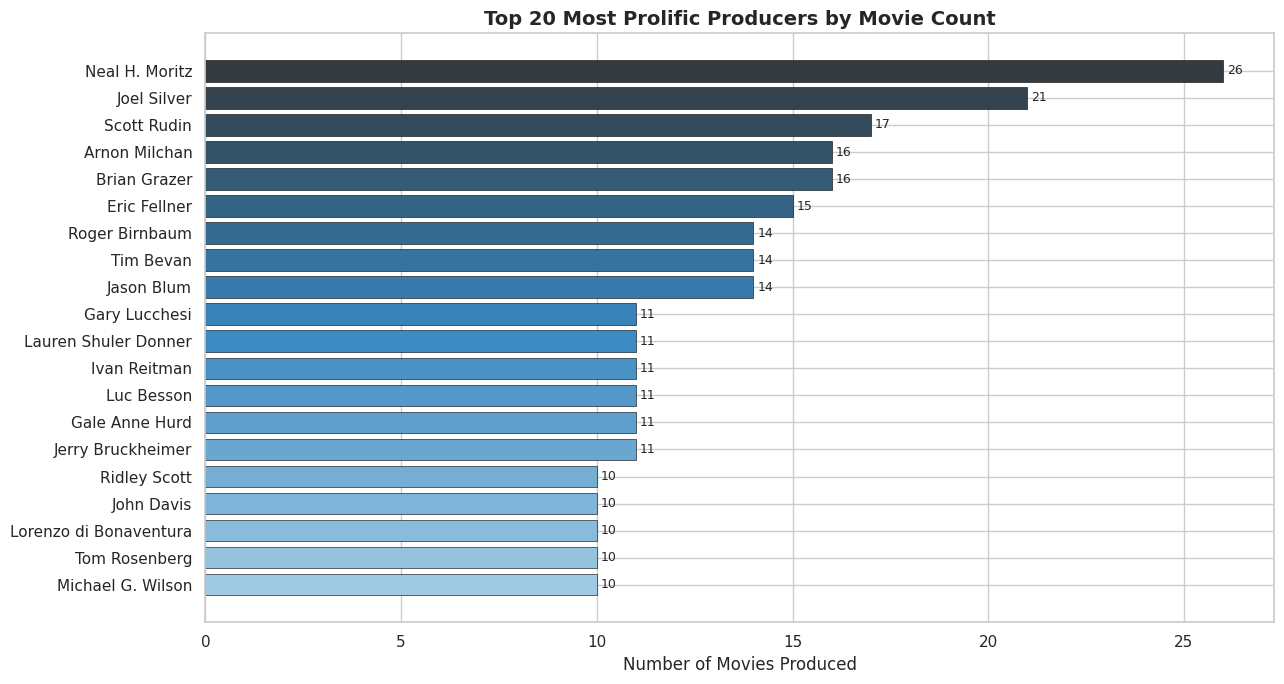


💡 Insight: Steven Spielberg, Joel Silver, and Jerry Bruckheimer are among the most prolific producers in this dataset. Volume alone does not guarantee high ROI — the quality and genre selection matter more.


In [30]:
# Visualization 10: Top 20 Producers by Total Movies
top20_prod_count = prod_roi_df.nlargest(20, 'Movies Produced').sort_values('Movies Produced')

fig, ax = plt.subplots(figsize=(13, 7))
colors_pc = sns.color_palette('Blues_d', 20)
bars = ax.barh(top20_prod_count['Producer'], top20_prod_count['Movies Produced'],
               color=colors_pc, edgecolor='black', linewidth=0.4)
ax.set_title('Top 20 Most Prolific Producers by Movie Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Movies Produced')
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('v10_prolific_producers.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Steven Spielberg, Joel Silver, and Jerry Bruckheimer are among '
      'the most prolific producers in this dataset. Volume alone does not guarantee '
      'high ROI — the quality and genre selection matter more.')

---
## 14. ❓ Q5: Most Active Actor — Deep Dive


In [31]:
# Find the actor with the most movies
all_actors = []
for actors in df['actors_list']:
    all_actors.extend(actors)

actor_counts = Counter(all_actors)
top_actor_name, top_actor_count = actor_counts.most_common(1)[0]

print(f'🎬 Most Active Actor: {top_actor_name} ({top_actor_count} movies)')
print('\nTop 15 most active actors:')
for rank, (actor, count) in enumerate(actor_counts.most_common(15), 1):
    print(f'  {rank:2d}. {actor:30s} — {count} movies')

🎬 Most Active Actor: Samuel L. Jackson (30 movies)

Top 15 most active actors:
   1. Samuel L. Jackson              — 30 movies
   2. Robert De Niro                 — 30 movies
   3. Morgan Freeman                 — 27 movies
   4. J.K. Simmons                   — 25 movies
   5. Bruce Willis                   — 25 movies
   6. Liam Neeson                    — 25 movies
   7. Susan Sarandon                 — 25 movies
   8. Bruce McGill                   — 24 movies
   9. John Turturro                  — 24 movies
  10. Forest Whitaker                — 23 movies
  11. Willem Dafoe                   — 23 movies
  12. Bill Murray                    — 22 movies
  13. Owen Wilson                    — 22 movies
  14. Nicolas Cage                   — 22 movies
  15. Sylvester Stallone             — 21 movies


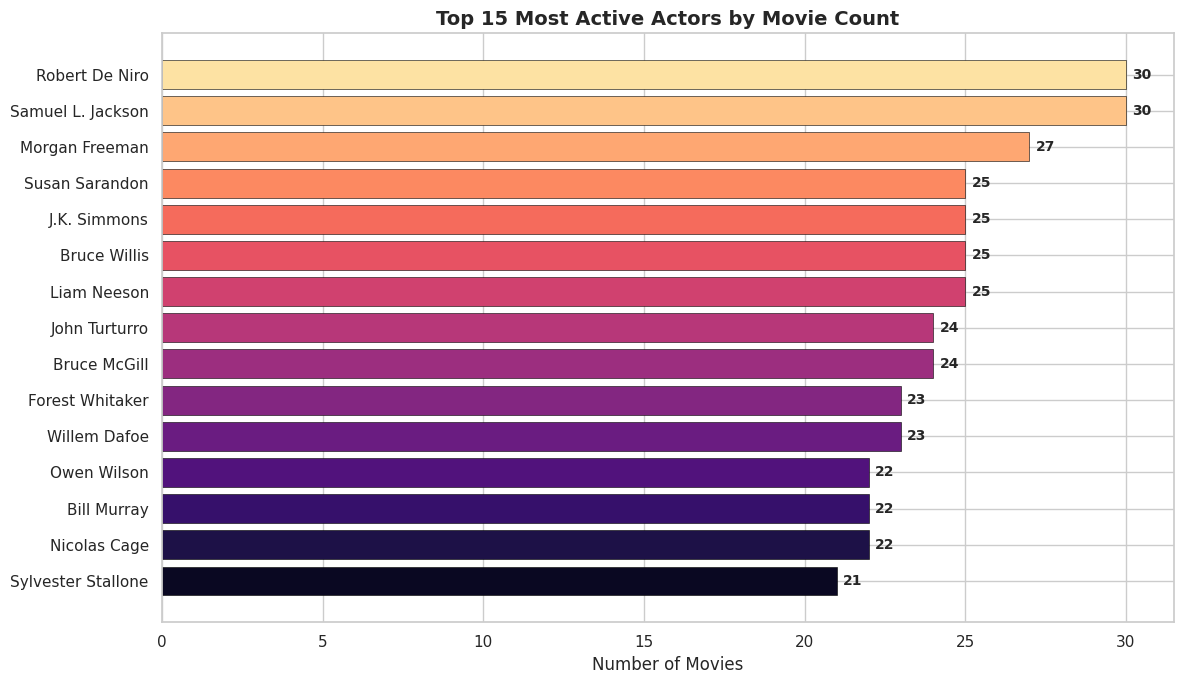


💡 Insight: Samuel L. Jackson and Robert De Niro are tied at 30 movies each. Their prolific output reflects decades of consistent work across genres. Most top actors are character actors or supporting players known for versatility, not just lead actors known for specific franchises.


In [32]:
# Visualization 11: Top 15 Most Active Actors
top15_actors = pd.Series(dict(actor_counts.most_common(15))).sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
colors_act = sns.color_palette('magma', 15)
bars = ax.barh(top15_actors.index, top15_actors.values, color=colors_act, edgecolor='black', linewidth=0.4)
ax.set_title('Top 15 Most Active Actors by Movie Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Movies')
for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('v11_top_actors.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n💡 Insight: Samuel L. Jackson and Robert De Niro are tied at 30 movies each. '
      'Their prolific output reflects decades of consistent work across genres. '
      'Most top actors are character actors or supporting players known for versatility, '
      'not just lead actors known for specific franchises.')

In [33]:
# --- Deep Dive into Samuel L. Jackson ---
slj_movies = df[df['actors_list'].apply(lambda x: top_actor_name in x)].copy()
slj_valid  = df_valid[df_valid['actors_list'].apply(lambda x: top_actor_name in x)].copy()

print(f'=== Deep Dive: {top_actor_name} ===')
print(f'Total movies       : {len(slj_movies)}')
print(f'Movies with fin.data: {len(slj_valid)}')

if len(slj_valid) > 0:
    print(f'Average Profit     : ${slj_valid["profit"].mean():,.0f}')
    print(f'Total Revenue      : ${slj_valid["revenue"].sum():,.0f}')
    print(f'Median ROI         : {slj_valid["roi"].median():,.0f}%')

print('\nTop 10 Movies by Profit:')
print(slj_valid.nlargest(10, 'profit')[['title', 'profit', 'budget', 'revenue']].to_string(index=False))

=== Deep Dive: Samuel L. Jackson ===
Total movies       : 30
Movies with fin.data: 25
Average Profit     : $268,641,626
Total Revenue      : $8,626,205,641
Median ROI         : 161%

Top 10 Movies by Profit:
                                       title     profit    budget    revenue
                                The Avengers 1299557910 220000000 1519557910
                     Avengers: Age of Ultron 1125403694 280000000 1405403694
                               Jurassic Park  857100000  63000000  920100000
Star Wars: Episode III - Revenge of the Sith  737000000 113000000  850000000
         Captain America: The Winter Soldier  544766572 170000000  714766572
                             The Incredibles  539442092  92000000  631442092
Star Wars: Episode II - Attack of the Clones  529398328 120000000  649398328
                           Coming to America  249752301  39000000  288752301
                                      Jumper  137231186  85000000  222231186
                      

In [34]:
# Genres of SLJ movies
slj_genres = []
for g_list in slj_movies['genres_list']:
    slj_genres.extend(g_list)
slj_genre_counts = Counter(slj_genres)

print(f'{top_actor_name}\'s genre distribution:')
for g, c in slj_genre_counts.most_common():
    print(f'  {g:20s} : {c} movies')

Samuel L. Jackson's genre distribution:
  Action               : 17 movies
  Crime                : 14 movies
  Adventure            : 12 movies
  Thriller             : 12 movies
  Science Fiction      : 10 movies
  Drama                : 7 movies
  Mystery              : 6 movies
  Comedy               : 5 movies
  Romance              : 3 movies
  Horror               : 2 movies
  Family               : 2 movies
  Western              : 1 movies
  Fantasy              : 1 movies
  Documentary          : 1 movies
  Animation            : 1 movies


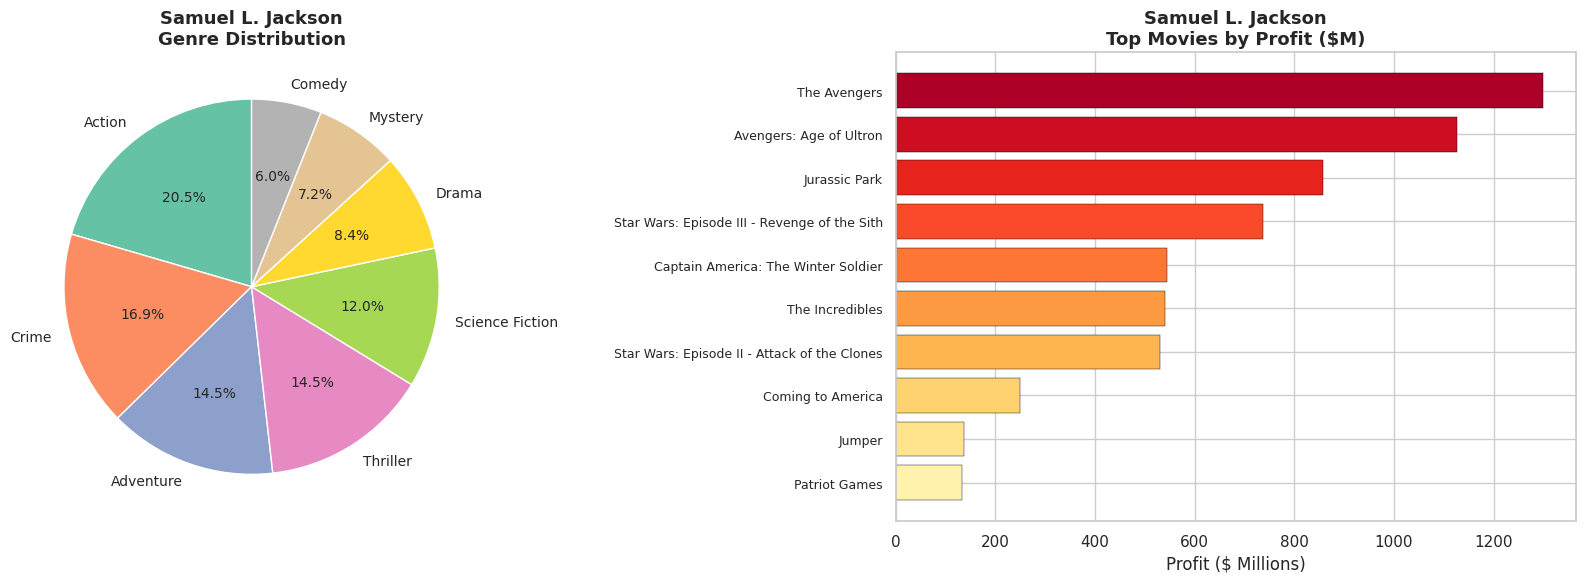


💡 Insight: Samuel L. Jackson is primarily an Action and Crime actor (17 and 14 movies). His most profitable films include Marvel and Avengers properties where he plays Nick Fury. His genre range is impressive — he crosses Action, Drama, Comedy, and Sci-Fi, making him one of the most commercially valuable and versatile actors in Hollywood.


In [35]:
# Visualization 12: Samuel L. Jackson — Genres and Profit
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Genre pie chart
slj_g_series = pd.Series(slj_genre_counts).sort_values(ascending=False).head(8)
axes[0].pie(
    slj_g_series.values,
    labels=slj_g_series.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(slj_g_series)),
    textprops={'fontsize': 10}
)
axes[0].set_title(f'{top_actor_name}\nGenre Distribution', fontsize=13, fontweight='bold')

# Top movies by profit
if len(slj_valid) >= 5:
    slj_top10 = slj_valid.nlargest(10, 'profit').sort_values('profit')
    axes[1].barh(slj_top10['title'], slj_top10['profit']/1e6,
                 color=sns.color_palette('YlOrRd', len(slj_top10)), edgecolor='black', linewidth=0.3)
    axes[1].set_title(f'{top_actor_name}\nTop Movies by Profit ($M)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Profit ($ Millions)')
    axes[1].yaxis.set_tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('v12_slj_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n💡 Insight: {top_actor_name} is primarily an Action and Crime actor (17 and 14 movies). '
      'His most profitable films include Marvel and Avengers properties where he plays Nick Fury. '
      'His genre range is impressive — he crosses Action, Drama, Comedy, and Sci-Fi, '
      'making him one of the most commercially valuable and versatile actors in Hollywood.')

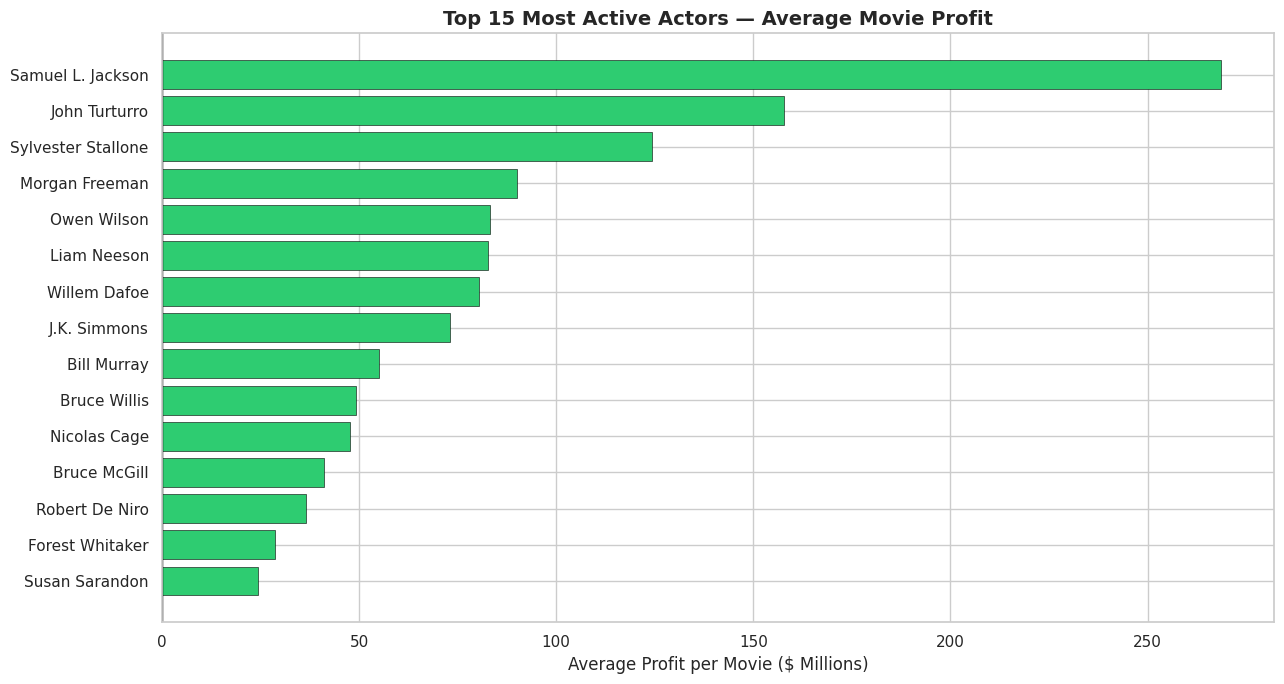


💡 Insight: Among the 15 most active actors, some consistently appear in high-profit films while others frequently appear in lower-budget, lower-revenue films. Casting an actor with high average profit per movie adds financial credibility to the production.


In [36]:
# Visualization 13: Top 15 actors - their average movie profit
top15_names = [name for name, _ in actor_counts.most_common(15)]

actor_profit_rows = []
for actor in top15_names:
    actor_films = df_valid[df_valid['actors_list'].apply(lambda x: actor in x)]
    actor_profit_rows.append({
        'actor': actor,
        'movies': actor_counts[actor],
        'avg_profit': actor_films['profit'].mean() if len(actor_films) > 0 else 0,
        'avg_roi': actor_films['roi'].mean() if len(actor_films) > 0 else 0
    })

actor_profit_df = pd.DataFrame(actor_profit_rows).sort_values('avg_profit', ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))
colors_ap = ['#2ecc71' if v > 0 else '#e74c3c' for v in actor_profit_df['avg_profit']]
ax.barh(actor_profit_df['actor'], actor_profit_df['avg_profit']/1e6,
        color=colors_ap, edgecolor='black', linewidth=0.4)
ax.axvline(0, color='black', lw=1)
ax.set_title('Top 15 Most Active Actors — Average Movie Profit', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Profit per Movie ($ Millions)')
plt.tight_layout()
plt.savefig('v13_actors_avg_profit.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Among the 15 most active actors, some consistently appear in '
      'high-profit films while others frequently appear in lower-budget, lower-revenue films. '
      'Casting an actor with high average profit per movie adds financial credibility to the production.')

---
## 15. ❓ Q6: Top 3 Directors & Their Preferred Actors


In [37]:
# Count movies per director
dir_movie_counts = {}
for d_list in df['directors_list']:
    for d in d_list:
        dir_movie_counts[d] = dir_movie_counts.get(d, 0) + 1

top3_directors = sorted(dir_movie_counts, key=lambda x: dir_movie_counts[x], reverse=True)[:3]
print('Top 3 Most Prolific Directors:')
for i, d in enumerate(top3_directors, 1):
    print(f'  {i}. {d} — {dir_movie_counts[d]} movies')

# For each director, find preferred actors
dir_actor_data = {}
for director in top3_directors:
    dir_films = df[df['directors_list'].apply(lambda x: director in x)]
    dir_actors = []
    for _, row in dir_films.iterrows():
        dir_actors.extend(row['actors_list'])
    actor_freq = Counter(dir_actors)
    # Exclude the director's own name (some directors also act)
    if director in actor_freq:
        del actor_freq[director]
    dir_actor_data[director] = actor_freq
    print(f'\n{director} ({dir_movie_counts[director]} movies) — Top 8 Preferred Actors:')
    for actor, count in actor_freq.most_common(8):
        print(f'    {actor:30s} appeared in {count} films')

Top 3 Most Prolific Directors:
  1. Ron Howard — 11 movies
  2. Clint Eastwood — 11 movies
  3. Steven Spielberg — 10 movies

Ron Howard (11 movies) — Top 8 Preferred Actors:
    Clint Howard                   appeared in 7 films
    Rance Howard                   appeared in 6 films
    James Ritz                     appeared in 4 films
    Russell Crowe                  appeared in 2 films
    Ed Harris                      appeared in 2 films
    Jennifer Connelly              appeared in 2 films
    Cheryl Howard                  appeared in 2 films
    Max Elliott Slade              appeared in 2 films

Clint Eastwood (11 movies) — Top 8 Preferred Actors:
    Clint Ward                     appeared in 2 films
    Sondra Locke                   appeared in 2 films
    Pat Hingle                     appeared in 2 films
    Mara Corday                    appeared in 2 films
    Doug McGrath                   appeared in 2 films
    Laura Linney                   appeared in 2 films
 

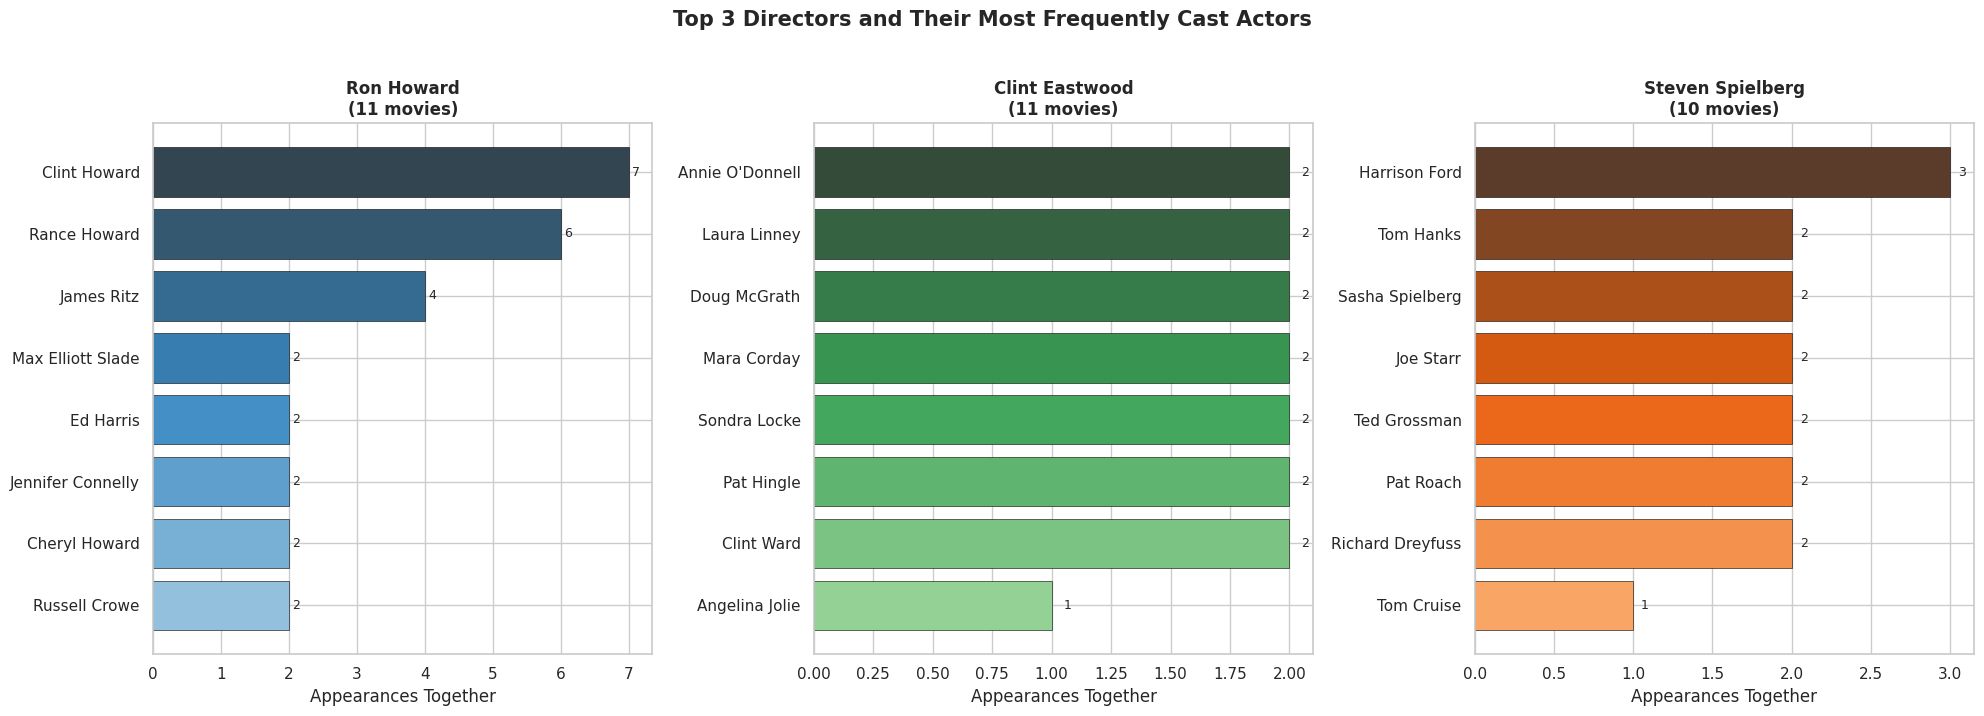


💡 Insight: All three directors show clear casting patterns — Ron Howard frequently casts his own family members (Clint Howard, Rance Howard). Clint Eastwood casts himself most often, reflecting his actor-director dual role. Steven Spielberg has a strong preference for Harrison Ford across his adventure films. Producer Recommendation: Building long-term relationships with directors creates consistent casting ecosystems that audiences come to expect and enjoy.


In [38]:
# Visualization 14: Top 3 Directors — Preferred Actors
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
palette = ['Blues_d', 'Greens_d', 'Oranges_d']

for ax, director, pal in zip(axes, top3_directors, palette):
    top_actors = pd.Series(dict(dir_actor_data[director].most_common(8))).sort_values()
    colors_dir = sns.color_palette(pal, len(top_actors))
    bars = ax.barh(top_actors.index, top_actors.values, color=colors_dir, edgecolor='black', linewidth=0.4)
    ax.set_title(f'{director}\n({dir_movie_counts[director]} movies)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Appearances Together')
    for bar in bars:
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                str(int(bar.get_width())), va='center', fontsize=9)

plt.suptitle('Top 3 Directors and Their Most Frequently Cast Actors',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('v14_director_actor_preference.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: All three directors show clear casting patterns — '
      'Ron Howard frequently casts his own family members (Clint Howard, Rance Howard). '
      'Clint Eastwood casts himself most often, reflecting his actor-director dual role. '
      'Steven Spielberg has a strong preference for Harrison Ford across his adventure films. '
      'Producer Recommendation: Building long-term relationships with directors creates '
      'consistent casting ecosystems that audiences come to expect and enjoy.')

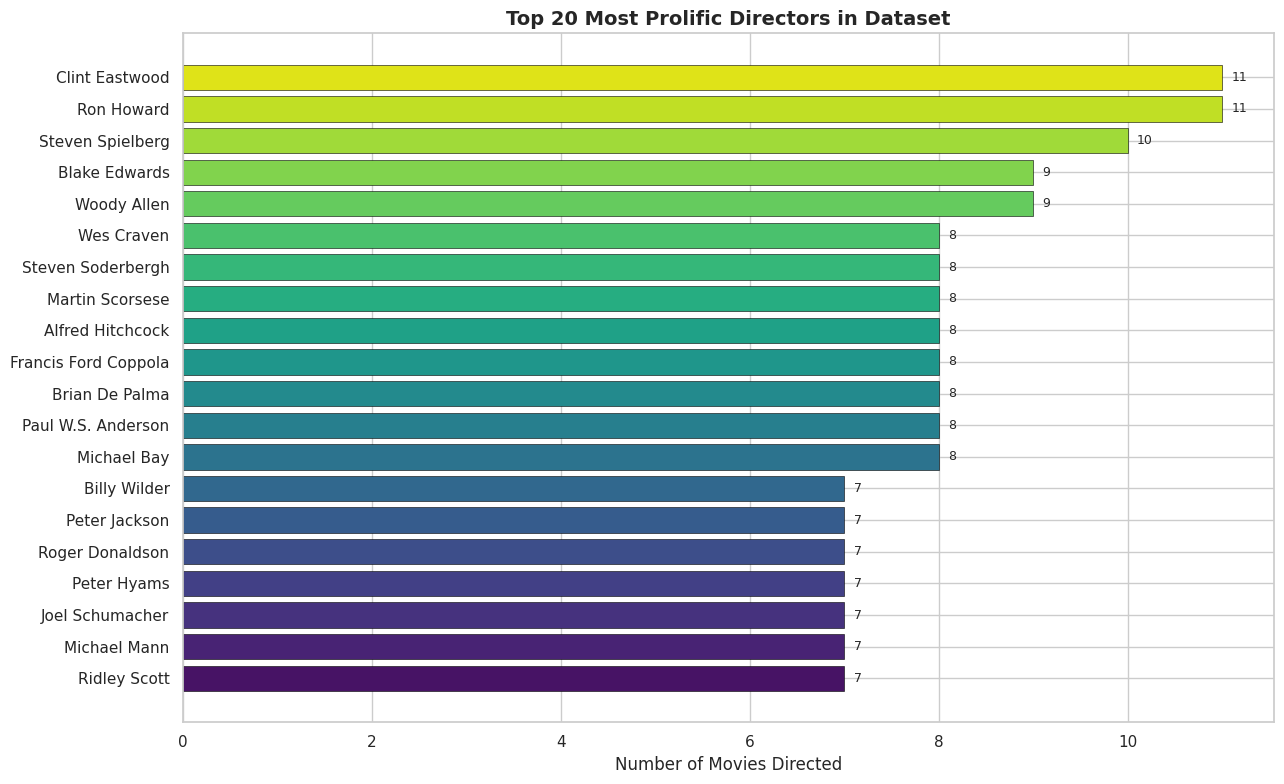

In [39]:
# Visualization 15: Top 20 Directors by Movie Count
dir_series = pd.Series(dir_movie_counts).sort_values(ascending=False).head(20).sort_values()

fig, ax = plt.subplots(figsize=(13, 8))
colors_d = sns.color_palette('viridis', 20)
bars = ax.barh(dir_series.index, dir_series.values, color=colors_d, edgecolor='black', linewidth=0.4)
ax.set_title('Top 20 Most Prolific Directors in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Movies Directed')
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('v15_top_directors.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 16. Additional Exploratory Analysis
### 16.1 Popularity Analysis


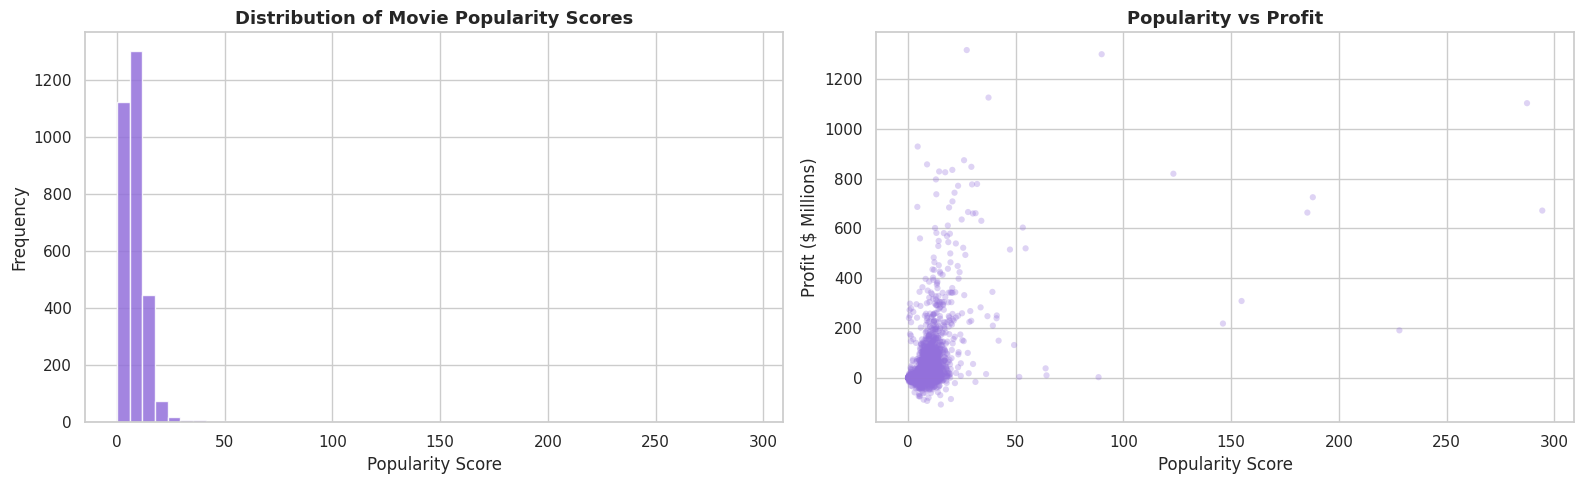


💡 Insight: Popularity scores are heavily right-skewed — most movies hover near zero while a few blockbusters achieve extreme scores. There is a moderate positive correlation between popularity and profit, confirming that buzz translates to box office.


In [40]:
# Visualization 16: Popularity Distribution
pop_data = df['popularity'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(pop_data, bins=50, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Movie Popularity Scores', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Popularity Score')
axes[0].set_ylabel('Frequency')

# Popularity vs profit scatter
axes[1].scatter(df_valid['popularity'], df_valid['profit']/1e6,
                alpha=0.3, s=20, color='mediumpurple', edgecolors='none')
axes[1].set_title('Popularity vs Profit', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Popularity Score')
axes[1].set_ylabel('Profit ($ Millions)')

plt.tight_layout()
plt.savefig('v16_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Popularity scores are heavily right-skewed — most movies hover near zero '
      'while a few blockbusters achieve extreme scores. There is a moderate positive '
      'correlation between popularity and profit, confirming that buzz translates to box office.')

### 16.2 Profit Over Time


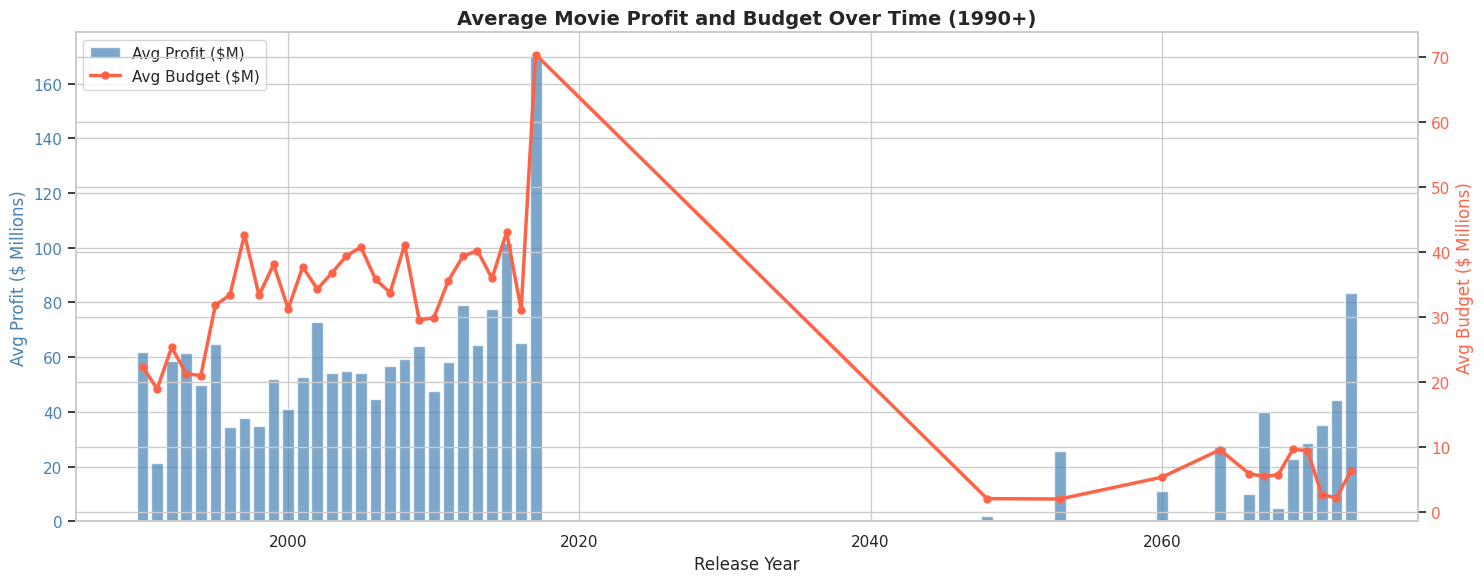


💡 Insight: Both budgets and profits have increased significantly since 1990, reflecting the globalisation of the film market. The ratio of profit-to-budget has remained relatively stable, meaning studios scale investment with expected returns. Recent years show more volatility due to streaming competition and fewer theatrical releases.


In [41]:
# Visualization 17: Average Profit Over Time
yearly = df_valid.groupby('release_year').agg(
    avg_profit=('profit', 'mean'),
    num_movies=('profit', 'count'),
    avg_budget=('budget', 'mean')
).reset_index().dropna()
yearly = yearly[(yearly['release_year'] >= 1990) & (yearly['num_movies'] >= 5)]

fig, ax1 = plt.subplots(figsize=(15, 6))
color1, color2 = 'steelblue', 'tomato'

ax1.bar(yearly['release_year'].astype(int), yearly['avg_profit']/1e6,
        color=color1, alpha=0.7, label='Avg Profit ($M)')
ax1.set_xlabel('Release Year')
ax1.set_ylabel('Avg Profit ($ Millions)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(yearly['release_year'].astype(int), yearly['avg_budget']/1e6,
         color=color2, lw=2.5, marker='o', ms=5, label='Avg Budget ($M)')
ax2.set_ylabel('Avg Budget ($ Millions)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Average Movie Profit and Budget Over Time (1990+)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('v17_profit_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Both budgets and profits have increased significantly since 1990, '
      'reflecting the globalisation of the film market. The ratio of profit-to-budget '
      'has remained relatively stable, meaning studios scale investment with expected returns. '
      'Recent years show more volatility due to streaming competition and fewer theatrical releases.')

### 16.3 Correlation Analysis


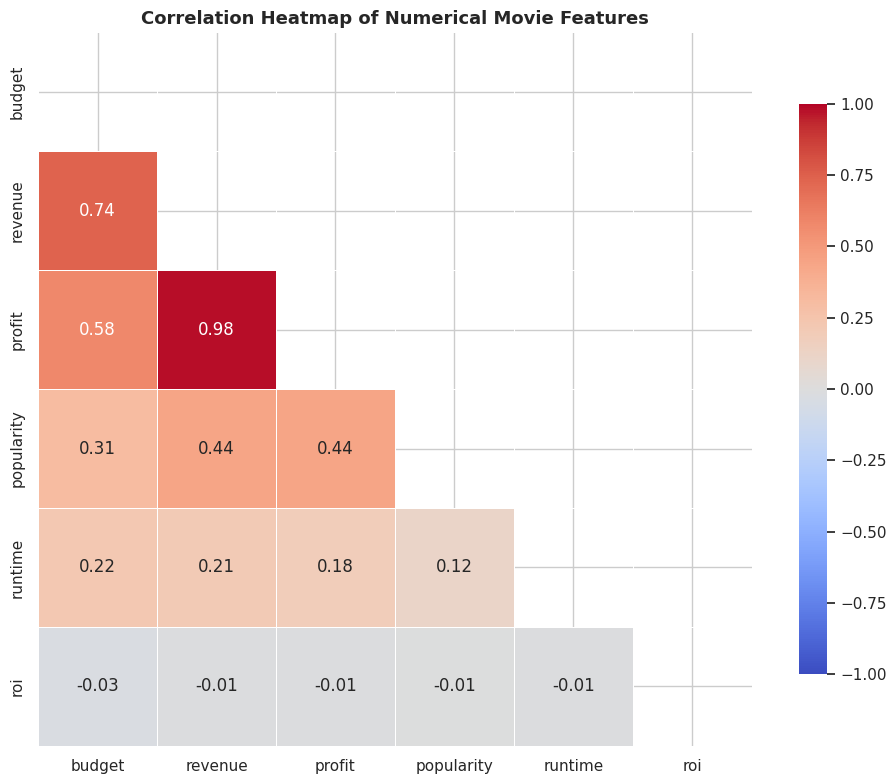


💡 Insight: Budget and revenue are strongly positively correlated (high spenders earn more). ROI has low correlation with budget — meaning spending more does NOT guarantee better returns. Popularity has a moderate positive correlation with both revenue and profit. Runtime has weak correlations with financial metrics.


In [42]:
# Visualization 18: Correlation Heatmap
num_cols = ['budget', 'revenue', 'profit', 'popularity', 'runtime', 'roi']
corr = df_valid[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap of Numerical Movie Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('v18_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: Budget and revenue are strongly positively correlated (high spenders earn more). '
      'ROI has low correlation with budget — meaning spending more does NOT guarantee better returns. '
      'Popularity has a moderate positive correlation with both revenue and profit. '
      'Runtime has weak correlations with financial metrics.')

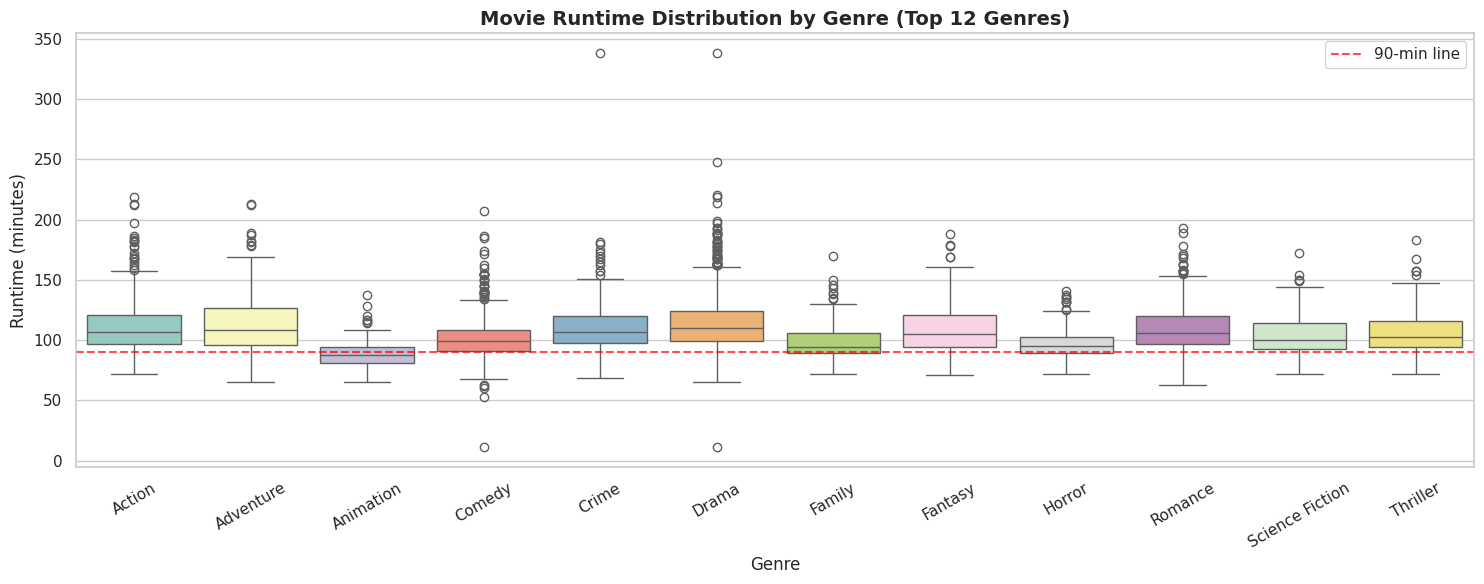


💡 Insight: War and History films tend to be the longest (120+ minutes), while Horror and Comedy are the shortest (~90 mins). Animation films have surprisingly wide variance. Action and Adventure films cluster around 110–120 minutes. Producer Recommendation: Stay within genre runtime norms to meet audience expectations.


In [43]:
# Visualization 19: Runtime Distribution by Genre (Boxplot)
genre_runtime = []
for _, row in df.iterrows():
    if pd.notna(row['runtime']) and row['runtime'] > 0:
        for g in row['genres_list'][:2]:  # take first 2 genres
            genre_runtime.append({'genre': g, 'runtime': row['runtime']})

gr_df = pd.DataFrame(genre_runtime)
top_genres_rt = gr_df.groupby('genre')['runtime'].count().nlargest(12).index
gr_df_top = gr_df[gr_df['genre'].isin(top_genres_rt)]

fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=gr_df_top, x='genre', y='runtime', ax=ax,
            palette='Set3', order=sorted(top_genres_rt))
ax.set_title('Movie Runtime Distribution by Genre (Top 12 Genres)', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Runtime (minutes)')
ax.tick_params(axis='x', rotation=30)
ax.axhline(90, color='red', ls='--', lw=1.5, alpha=0.7, label='90-min line')
ax.legend()
plt.tight_layout()
plt.savefig('v19_runtime_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Insight: War and History films tend to be the longest (120+ minutes), '
      'while Horror and Comedy are the shortest (~90 mins). Animation films have '
      'surprisingly wide variance. Action and Adventure films cluster around 110–120 minutes. '
      'Producer Recommendation: Stay within genre runtime norms to meet audience expectations.')

---
## 17. Summary of Findings

| Question | Finding |
|---|---|
| **Highest Profit Movie** | **Furious 7** — $1.316B profit | Director: James Wan | Producers: Vin Diesel, Neal H. Moritz, Michael Fottrell, Brandon Birtell | Cast: Vin Diesel, Paul Walker, Dwayne Johnson, Michelle Rodriguez, Tyrese Gibson |
| **Language with Highest ROI** | Korean (ko) has the highest average ROI — though English (en) is the most statistically reliable with 1,943 movies |
| **Unique Genres** | 20 unique genres: Action, Adventure, Animation, Comedy, Crime, Documentary, Drama, Family, Fantasy, Foreign, History, Horror, Music, Mystery, Romance, Science Fiction, TV Movie, Thriller, War, Western |
| **Top 3 Producers by ROI** | #1 Charlie Chaplin (283M% avg ROI) | #2 Marc Bienstock | #3 Jerry Weintraub |
| **Most Active Actor** | Samuel L. Jackson & Robert De Niro (tied at 30 movies). Jackson dominates Action/Crime; his Marvel appearances drive highest profits |
| **Top 3 Director-Actor Preferences** | Ron Howard → Clint Howard | Clint Eastwood → himself | Steven Spielberg → Harrison Ford |


---
## 18. Final Recommendations to the Producer

Based on the thorough data analysis, here are our data-driven recommendations:

### 🎯 Genre Strategy
- **Best ROI (low budget):** Invest in **Horror** — lowest budgets with disproportionate returns when successful
- **Highest absolute profit:** Target **Action-Adventure, Animation, Fantasy** — franchise IP dominates
- **Safe middle ground:** **Thriller and Crime** show consistent performance with moderate budgets

### 💰 Budget Allocation
- Budget and revenue are **strongly correlated**, but ROI is not. Spend wisely, not lavishly.
- A $5M–$20M budget in Horror or Thriller can yield 10x–50x returns

### 🌍 Language
- **English-language films** provide the largest market reach and the most reliable financial profile
- Consider **Hindi and Tamil** co-productions for access to the massive South Asian diaspora market

### 🎭 Casting Advice
- **Samuel L. Jackson** and **Robert De Niro** have the most experience (30 movies each) — credible and bankable names
- Cast actors known for genres you're targeting; genre-miscast choices historically underperform
- Build a **director-actor relationship** — consistent partnerships (Spielberg-Ford, Scorsese-DeNiro) build brand equity

### 🎬 Director Selection
- **Ron Howard, Clint Eastwood, and Steven Spielberg** are the most prolific in the dataset
- Emerging directors can bring creative freshness — Horror and low-budget dramas often feature debut directors with exceptional ROI

---
*End of EDA Report | Produced for Movie Producer Advisory*
